# GGA Network Training - Step 3: Multi-Architecture Comparison

## Training Approaches:
- **A**: Atomization Energy (AE) only
- **B**: AE + Density Matrix matching
- **C**: AE + Grid Density matching
- **D1**: Delta-Learning (energy): E_NN - E_PBE ≈ E_CCSD - E_PBE
- **D2**: Delta-E + Delta-DM
- **D3**: Delta-E + Delta-Grid

## Architecture Variants (6):
- shallow, shallow_attn, medium, medium_attn, deep, deep_attn
- All use GGA_FxNet_sigma/GGA_FcNet_sigma with [rho, sigma] input

## References:
- **Targets**: CCSD
- **Baseline** (for delta): PBE

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import os
import gc
from functools import partial

from pyscf import gto, dft, scf, cc
from pyscfad import gto as gto_ad, dft as dft_ad

# Enable implicit differentiation for SCF - much faster training!                                                                                                     
from pyscfad._src._config import config                                                                                                                               
config.update('pyscfad_scf_implicit_diff', True)                                                                                                                      
print(f"SCF implicit diff enabled: {config.scf_implicit_diff}") 

import xcquinox as xce
from xcquinox.xc import RXCModel_GGA
from xcquinox.pyscf import eval_xc_gga_j2

# JAX memory management - release memory when needed
jax.config.update("jax_enable_x64", True)
#pyscfad doesn't provide SCF on GPU capability, forced to use CPU only
jax.config.update('jax_default_device', jax.devices('cpu')[0])
# Clear compilation caches periodically to free memory
def clear_memory():
    """Clear JAX caches and run garbage collection."""
    jax.clear_caches()
    gc.collect()

print(f'JAX: {jax.__version__}, Device: {jax.devices()[0]}')

BASIS = 'def2-svp'
GRID_LEVEL = 1
CHECKPOINT_BASE = 'checkpoints_v3'
os.makedirs(CHECKPOINT_BASE, exist_ok=True)

SCF implicit diff enabled: True
JAX: 0.7.0, Device: cuda:0


In [2]:
print(xce.__file__)                                                                                       

/home/awills/Documents/Research/xcquinox/xcquinox/__init__.py


In [3]:
# =============================================================================
# ARCHITECTURES - Define before CHECKPOINT_DIRS
# =============================================================================
# NOTE: eval_xc_gga_j2 only passes [rho, sigma] (2 features) to networks.
# Extended features (laplacian, dm_features) require a modified eval_xc.
# For now, only architectures with use_laplacian=False AND use_dm_features=False work.
# We vary depth/nodes/attention to create different architectures that work.

ARCHITECTURES = {
    'shallow': {'depth': 2, 'nodes': 8, 'use_self_attention': False},
    'shallow_attn': {'depth': 2, 'nodes': 8, 'use_self_attention': True},
    'medium': {'depth': 3, 'nodes': 16, 'use_self_attention': False},
    'medium_attn': {'depth': 3, 'nodes': 16, 'use_self_attention': True},
    'deep': {'depth': 4, 'nodes': 32, 'use_self_attention': False},
    'deep_attn': {'depth': 4, 'nodes': 32, 'use_self_attention': True},
}

SKIP_TRAINING = False
print(f'Architectures: {list(ARCHITECTURES.keys())}')

Architectures: ['shallow', 'shallow_attn', 'medium', 'medium_attn', 'deep', 'deep_attn']


In [4]:
# Create checkpoint directories for each approach and architecture
CHECKPOINT_DIRS = {
    'pretrain': os.path.join(CHECKPOINT_BASE, '01_pretrain'),
    'A_ae_only': os.path.join(CHECKPOINT_BASE, '02_A_ae_only'),
    'B_ae_dm': os.path.join(CHECKPOINT_BASE, '03_B_ae_dm'),
    'C_ae_grid': os.path.join(CHECKPOINT_BASE, '04_C_ae_grid'),
    'D1_delta_e': os.path.join(CHECKPOINT_BASE, '05_D1_delta_e'),
    'D2_delta_dm': os.path.join(CHECKPOINT_BASE, '06_D2_delta_dm'),
    'D3_delta_grid': os.path.join(CHECKPOINT_BASE, '07_D3_delta_grid'),
}

for approach, path in CHECKPOINT_DIRS.items():
    os.makedirs(path, exist_ok=True)
    for arch in ARCHITECTURES.keys():
        os.makedirs(os.path.join(path, arch), exist_ok=True)

print('Checkpoint directories created.')

Checkpoint directories created.


In [5]:
def create_network_pair(arch_name, seed=42):
    """Create xnet, cnet pair for given architecture.
    
    Uses GGA_FxNet_sigma and GGA_FcNet_sigma which expect [rho, sigma] input
    and work with eval_xc_gga_j2.
    """
    config = ARCHITECTURES[arch_name]
    depth = config['depth']
    nodes = config['nodes']
    use_attn = config['use_self_attention']
    
    xnet = xce.net.GGA_FxNet_sigma(
        depth=depth,
        nodes=nodes,
        seed=seed,
        use_self_attention=use_attn
    )
    
    cnet = xce.net.GGA_FcNet_sigma(
        depth=depth,
        nodes=nodes,
        seed=seed+1,
        use_self_attention=use_attn
    )
    
    return xnet, cnet

# Create networks for all architectures
SEED = 42
networks = {}
for arch in ARCHITECTURES.keys():
    networks[arch] = {'xnet': None, 'cnet': None}
    xnet, cnet = create_network_pair(arch, SEED)
    networks[arch]['xnet'] = xnet
    networks[arch]['cnet'] = cnet
    config = ARCHITECTURES[arch]
    print(f'{arch}: depth={config["depth"]}, nodes={config["nodes"]}, attn={config["use_self_attention"]}')

shallow: depth=2, nodes=8, attn=False
shallow_attn: depth=2, nodes=8, attn=True
medium: depth=3, nodes=16, attn=False
medium_attn: depth=3, nodes=16, attn=True
deep: depth=4, nodes=32, attn=False
deep_attn: depth=4, nodes=32, attn=True


In [6]:
def create_mol(atoms, spin=0):
    mol = gto.Mole()
    mol.atom = atoms
    mol.basis = BASIS
    mol.spin = spin
    mol.build()
    return mol

def create_mol_ad(atoms, spin=0):
    mol = gto_ad.Mole()
    mol.atom = atoms
    mol.basis = BASIS
    mol.spin = spin
    mol.build()
    return mol

## 2. Pre-training on PBE Enhancement Factors

In [7]:
class PretrainLoss(eqx.Module):
    """MSE loss for pre-training enhancement factors.
    
    Networks output F = 1 + enhancement, but targets are F - 1.
    So we subtract 1 from predictions before computing MSE.
    """
    rho: jnp.ndarray
    sigma: jnp.ndarray
    target: jnp.ndarray
    
    def __init__(self, rho, sigma, target):
        self.rho = jnp.array(rho)
        self.sigma = jnp.array(sigma)
        self.target = jnp.array(target)
    
    def __call__(self, net, *args, **kwargs):
        """Compute MSE loss. Extra args from xcTrainer are ignored."""
        # Stack [rho, sigma] as (N, 2) array
        descriptors = jnp.stack([self.rho, self.sigma], axis=1)
        # Network outputs F = 1 + enhancement
        pred = jax.vmap(net)(descriptors).squeeze()
        # Subtract 1 because targets are F - 1
        pred = pred - 1.0
        return jnp.mean((pred - self.target)**2)

In [8]:
# Collect enhancement factor data from PBE (matches step2 approach)
pretrain_atoms = [('H', 1), ('He', 0), ('O', 2), ('N', 3)]
rho_all, sigma_all, Fx_all, Fc_all = [], [], [], []

for atom, spin in pretrain_atoms:
    mol = create_mol(f'{atom} 0 0 0', spin=spin)
    mf = dft.UKS(mol) if spin else dft.RKS(mol)
    mf.xc = 'pbe'
    mf.grids.level = GRID_LEVEL
    mf.grids.build()
    mf.kernel()
    
    # Use pyscf's eval_ao and eval_rho for proper GGA density format (matches step2)
    ao = mf._numint.eval_ao(mol, mf.grids.coords, deriv=1)
    dm = mf.make_rdm1()
    
    # Handle spin - split into alpha/beta
    if dm.ndim == 2:
        dm_alpha = dm * 0.5
        dm_beta = dm * 0.5
    else:
        dm_alpha = dm[0]
        dm_beta = dm[1]
    
    # Evaluate density on grid (GGA format: rho, grad_x, grad_y, grad_z)
    rho_alpha = mf._numint.eval_rho(mol, ao, dm_alpha, xctype='GGA', hermi=True)
    rho_beta = mf._numint.eval_rho(mol, ao, dm_beta, xctype='GGA', hermi=True)
    
    # Extract density and gradient components
    rho0 = rho_alpha[0] + rho_beta[0]  # Total density
    drho = rho_alpha[1:4] + rho_beta[1:4]  # Total gradient
    sigma = np.sum(drho**2, axis=0)
    
    # Total density in GGA format for eval_xc
    rho_total = rho_alpha + rho_beta  # Shape (4, N)
    
    # Filter low-density regions
    # valid = rho0 > 1e-6
    valid = rho0 > 1e-10
    rho0_v = rho0[valid]
    sigma_v = sigma[valid]
    rho_total_v = rho_total[:, valid]
    
    # Get PBE exchange and correlation energy densities
    # 'PBE,' = exchange only, ',PBE' = correlation only
    ex = mf._numint.eval_xc('PBE,', rho_total_v, spin=0)[0]
    ec = mf._numint.eval_xc(',PBE', rho_total_v, spin=0)[0]
    
    # Get LDA values for enhancement factor calculation
    # LDA only needs rho0 (scalar density), not gradient
    ex_lda = mf._numint.eval_xc('LDA_X,', rho0_v, spin=0)[0]
    ec_lda = mf._numint.eval_xc(',LDA_C_PW', rho0_v, spin=0)[0]
    
    # Enhancement factors (F - 1, matching step2)
    Fx = ex / (ex_lda + 1e-10) - 1
    Fc = ec / (ec_lda + 1e-10) - 1
    
    rho_all.extend(rho0_v)
    sigma_all.extend(sigma_v)
    Fx_all.extend(Fx)
    Fc_all.extend(Fc)

rho_all = np.array(rho_all)
sigma_all = np.array(sigma_all)
Fx_all = np.array(Fx_all)
Fc_all = np.array(Fc_all)
print(f'Collected {len(rho_all)} points for pre-training')
print(f'Fx range: [{Fx_all.min():.4f}, {Fx_all.max():.4f}]')
print(f'Fc range: [{Fc_all.min():.4f}, {Fc_all.max():.4f}]')

converged SCF energy = -0.498629446221046  <S^2> = 0.75  2S+1 = 2
converged SCF energy = -2.88446415545499
converged SCF energy = -74.9146643956912  <S^2> = 2.0018397  2S+1 = 3.0012262
converged SCF energy = -54.4665775578499  <S^2> = 3.751995  2S+1 = 4.0009974
Collected 13186 points for pre-training
Fx range: [0.0000, 0.8040]
Fc range: [-1.0000, -0.0000]


In [9]:
# Pre-train all architectures with gradient clipping and linear LR schedule
pretrain_losses = {}
PTSTEPS = 500
PT_LR_START = 1e-2
PT_LR_END = 1e-4
PT_GRAD_CLIP = 1.0

if not SKIP_TRAINING:
    for arch in ARCHITECTURES.keys():
        print(f'Pre-training {arch}...')
        xnet, cnet = networks[arch]['xnet'], networks[arch]['cnet']
        
        # Checkpoint directory for this architecture
        arch_dir = os.path.join(CHECKPOINT_DIRS['pretrain'], arch)
        
        # Linear LR schedule: start high, decay to low
        lr_schedule = optax.linear_schedule(
            init_value=PT_LR_START,
            end_value=PT_LR_END,
            transition_steps=PTSTEPS
        )
        
        # Optimizer with gradient clipping and scheduled LR
        optimizer = optax.chain(
            optax.clip_by_global_norm(PT_GRAD_CLIP),
            optax.adam(learning_rate=lr_schedule)
        )
        
        # Train exchange
        x_loss = PretrainLoss(rho_all, sigma_all, Fx_all)
        trainer_x = xce.train.xcTrainer(model=xnet, optim=optimizer, 
                                         loss=x_loss, steps=PTSTEPS, do_jit=True,
                                         serialize_every=50,
                                         checkpoint_dir=arch_dir)
        xnet_t, losses_x = trainer_x(1, xnet, [rho_all], [Fx_all])
        
        # Train correlation (need fresh optimizer state)
        lr_schedule_c = optax.linear_schedule(
            init_value=PT_LR_START,
            end_value=PT_LR_END,
            transition_steps=PTSTEPS
        )
        optimizer_c = optax.chain(
            optax.clip_by_global_norm(PT_GRAD_CLIP),
            optax.adam(learning_rate=lr_schedule_c)
        )
        
        c_loss = PretrainLoss(rho_all, sigma_all, Fc_all)
        trainer_c = xce.train.xcTrainer(model=cnet, optim=optimizer_c,
                                         loss=c_loss, steps=PTSTEPS, do_jit=True,
                                         serialize_every=50,
                                         checkpoint_dir=arch_dir)
        cnet_t, losses_c = trainer_c(1, cnet, [rho_all], [Fc_all])
        
        networks[arch]['xnet'] = xnet_t
        networks[arch]['cnet'] = cnet_t
        pretrain_losses[arch] = {'x': losses_x, 'c': losses_c}
        
        # Save final networks
        eqx.tree_serialise_leaves(os.path.join(arch_dir, 'xnet.eqx'), xnet_t)
        eqx.tree_serialise_leaves(os.path.join(arch_dir, 'cnet.eqx'), cnet_t)
        
        # Save losses
        np.save(os.path.join(arch_dir, 'losses_x.npy'), np.array(losses_x))
        np.save(os.path.join(arch_dir, 'losses_c.npy'), np.array(losses_c))
        
        print(f'  Done: X={losses_x[-1]:.6f}, C={losses_c[-1]:.6f}')
        print(f'  Saved to: {arch_dir}')
        
        # Clear memory after each architecture
        clear_memory()
    
    # Save all pretrain losses
    np.savez(os.path.join(CHECKPOINT_BASE, 'pretrain_losses.npz'),
             **{f'{arch}_x': pretrain_losses[arch]['x'] for arch in pretrain_losses},
             **{f'{arch}_c': pretrain_losses[arch]['c'] for arch in pretrain_losses})
    print('Pre-training complete! Losses saved.')

Pre-training shallow...
Epoch 0
Step = 0: initializing inp_model and inp_opt_state.
Epoch 0 :: Batch 1/1
Batch Loss = 0.6307199791485553
0, epoch_train_loss=0.6307199791485553
Epoch 1
Epoch 1 :: Batch 1/1
Batch Loss = 0.5662621927354894
1, epoch_train_loss=0.5662621927354894
Epoch 2
Epoch 2 :: Batch 1/1
Batch Loss = 0.490159597594444
2, epoch_train_loss=0.490159597594444
Epoch 3
Epoch 3 :: Batch 1/1
Batch Loss = 0.38241880002789824
3, epoch_train_loss=0.38241880002789824
Epoch 4
Epoch 4 :: Batch 1/1
Batch Loss = 0.05393927170723229
4, epoch_train_loss=0.05393927170723229
Epoch 5
Epoch 5 :: Batch 1/1
Batch Loss = 0.02703813025720375
5, epoch_train_loss=0.02703813025720375
Epoch 6
Epoch 6 :: Batch 1/1
Batch Loss = 0.01754437357051571
6, epoch_train_loss=0.01754437357051571
Epoch 7
Epoch 7 :: Batch 1/1
Batch Loss = 0.01212175752300902
7, epoch_train_loss=0.01212175752300902
Epoch 8
Epoch 8 :: Batch 1/1
Batch Loss = 0.008510841793291927
8, epoch_train_loss=0.008510841793291927
Epoch 9
Epoc

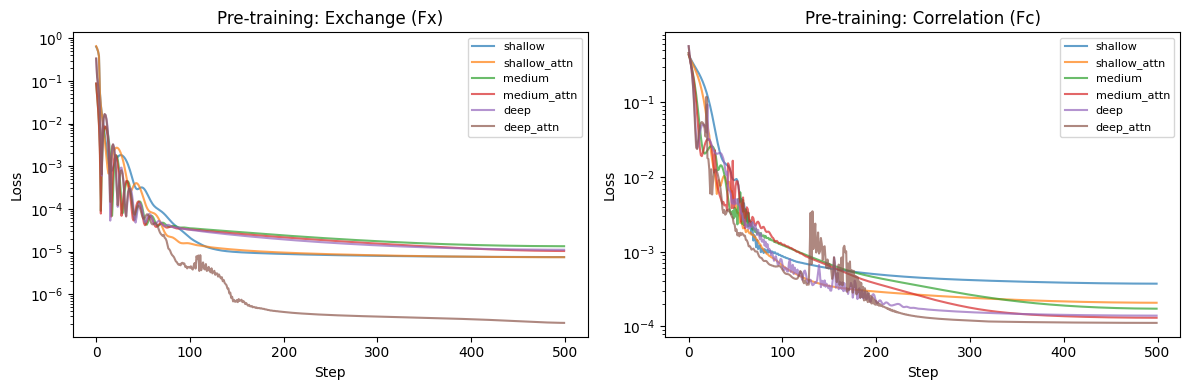

Saved: checkpoints_v3/pretrain_losses.png


In [10]:
# Plot pre-training losses
if pretrain_losses:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Exchange losses
    ax = axes[0]
    for arch in ARCHITECTURES.keys():
        if arch in pretrain_losses:
            ax.plot(pretrain_losses[arch]['x'], label=arch, alpha=0.7)
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('Pre-training: Exchange (Fx)')
    ax.legend(fontsize=8)
    ax.set_yscale('log')
    
    # Correlation losses
    ax = axes[1]
    for arch in ARCHITECTURES.keys():
        if arch in pretrain_losses:
            ax.plot(pretrain_losses[arch]['c'], label=arch, alpha=0.7)
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('Pre-training: Correlation (Fc)')
    ax.legend(fontsize=8)
    ax.set_yscale('log')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_BASE, 'pretrain_losses.png'), dpi=150)
    plt.show()
    print(f'Saved: {CHECKPOINT_BASE}/pretrain_losses.png')
else:
    print('No pre-training losses to plot.')

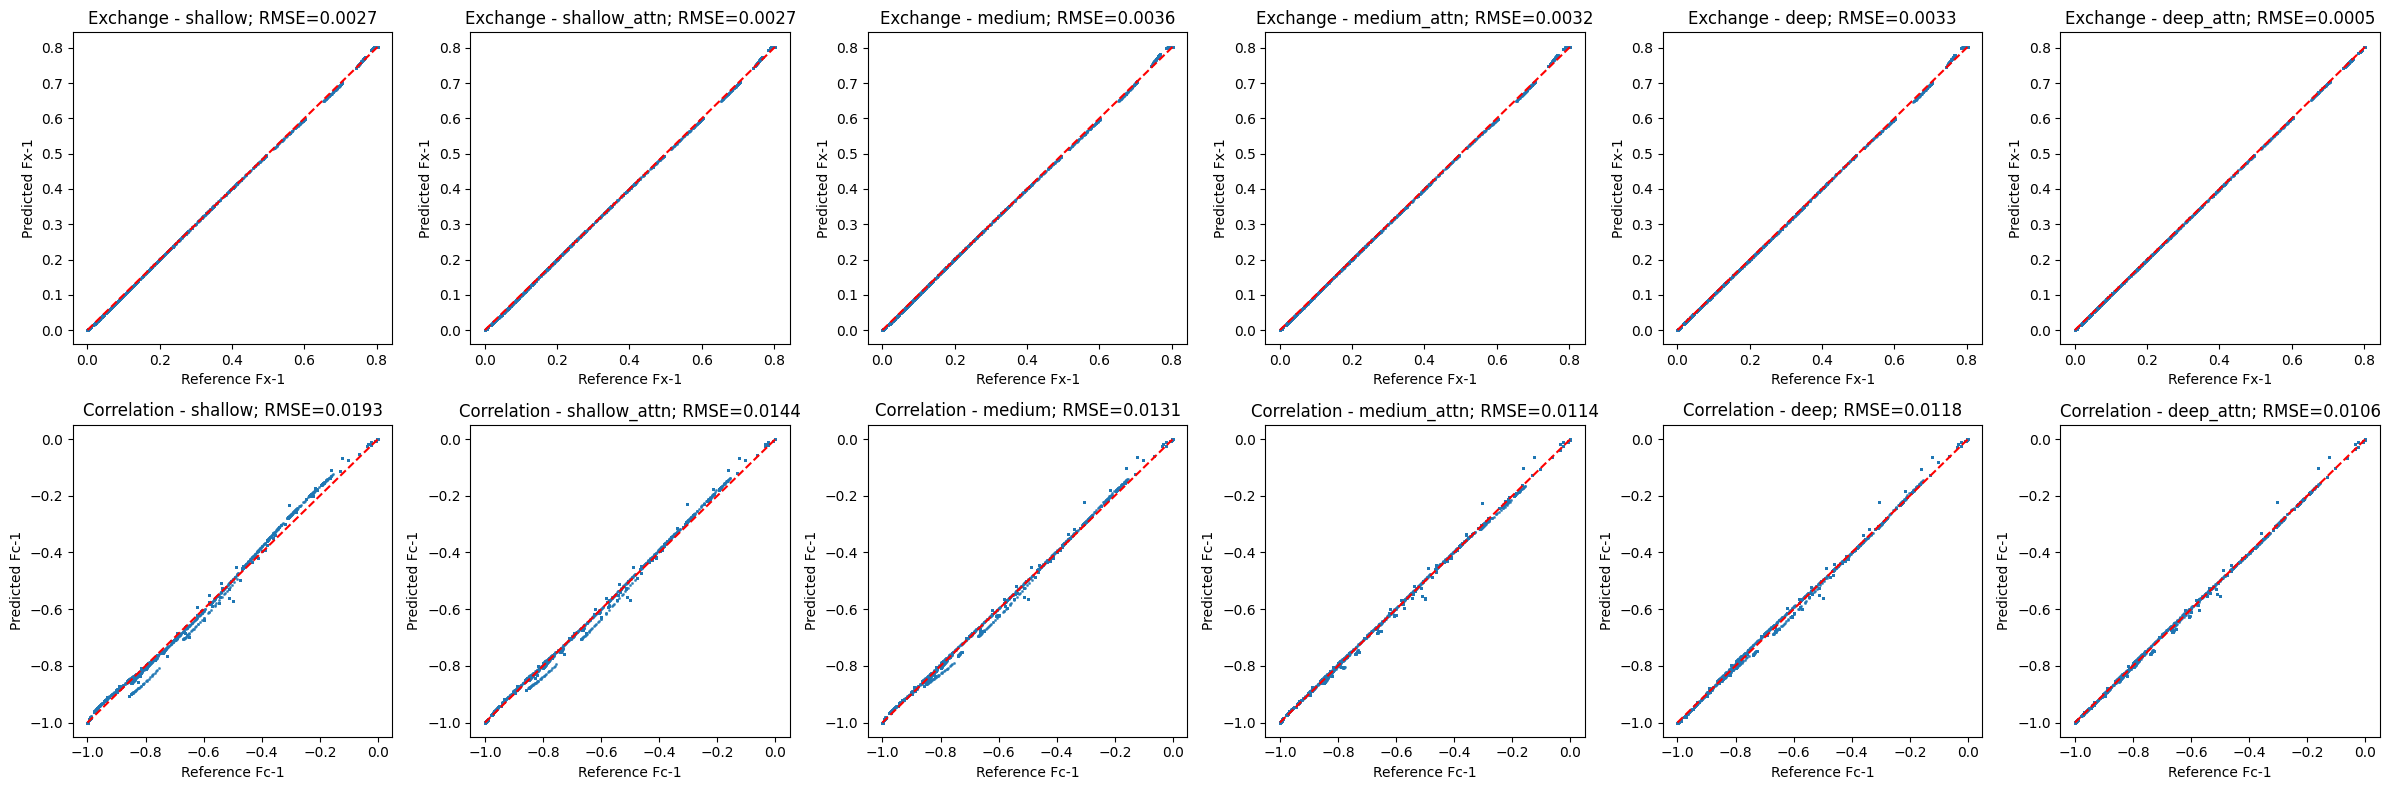

Saved: checkpoints_v3/01_pretrain/parity_plots.png


In [11]:
# Parity plots for pre-trained networks
if pretrain_losses:
    # Stack descriptors for evaluation
    descriptors = jnp.stack([rho_all, sigma_all], axis=1)
    
    # Compute RMSE for each architecture
    def compute_rmse(net, target):
        pred = jax.vmap(net)(descriptors) - 1.0  # Networks output F, targets are F-1
        return jnp.sqrt(jnp.mean((pred - target)**2)), pred
    
    fig, axes = plt.subplots(2, 6, figsize=(24, 8))
    
    for idx, arch in enumerate(ARCHITECTURES.keys()):
        xnet = networks[arch]['xnet']
        cnet = networks[arch]['cnet']
        
        # Exchange parity plot
        ax = axes[0, idx]
        rmse_x, pred_x = compute_rmse(xnet, Fx_all)
        ax.scatter(Fx_all, pred_x, alpha=0.5, s=1)
        ax.plot([Fx_all.min(), Fx_all.max()], [Fx_all.min(), Fx_all.max()], 'r--')
        ax.set_xlabel('Reference Fx-1')
        ax.set_ylabel('Predicted Fx-1')
        ax.set_title(f'Exchange - {arch}; RMSE={rmse_x:.4f}')
        
        # Correlation parity plot
        ax = axes[1, idx]
        rmse_c, pred_c = compute_rmse(cnet, Fc_all)
        ax.scatter(Fc_all, pred_c, alpha=0.5, s=1)
        ax.plot([Fc_all.min(), Fc_all.max()], [Fc_all.min(), Fc_all.max()], 'r--')
        ax.set_xlabel('Reference Fc-1')
        ax.set_ylabel('Predicted Fc-1')
        ax.set_title(f'Correlation - {arch}; RMSE={rmse_c:.4f}')
    
    plt.tight_layout()
    parity_path = os.path.join(CHECKPOINT_DIRS['pretrain'], 'parity_plots.png')
    plt.savefig(parity_path, dpi=150)
    plt.show()
    print(f'Saved: {parity_path}')
else:
    print('No pre-training results for parity plots.')

## 3. Training Data: CCSD Targets, PBE Baseline

In [12]:
# Training systems
H2O_COORDS = '''
O  0.0000  0.0000  0.1173
H  0.0000  0.7572 -0.4692
H  0.0000 -0.7572 -0.4692
'''

mol_H = create_mol('H 0 0 0', spin=1)
mol_O = create_mol('O 0 0 0', spin=2)
mol_H2O = create_mol(H2O_COORDS, spin=0)

mol_H_ad = create_mol_ad('H 0 0 0', spin=1)
mol_O_ad = create_mol_ad('O 0 0 0', spin=2)
mol_H2O_ad = create_mol_ad(H2O_COORDS, spin=0)

training_mols = {'H': mol_H, 'O': mol_O, 'H2O': mol_H2O}
training_mols_ad = {'H': mol_H_ad, 'O': mol_O_ad, 'H2O': mol_H2O_ad}
mol_names = ['H', 'O', 'H2O']
mols_ad_list = [mol_H_ad, mol_O_ad, mol_H2O_ad]

# Overlap matrices
overlaps = {name: mol.intor('int1e_ovlp') for name, mol in training_mols.items()}
print('Created training molecules and overlap matrices')

Created training molecules and overlap matrices


In [13]:
# Compute CCSD references (TARGETS)
# Use pyscf-ad grids for consistency with training
print('Computing CCSD references...')
ccsd_energies = {}
ccsd_dms = {}
ccsd_grid_rho = {}

for name, mol in training_mols.items():
    mol_ad = training_mols_ad[name]
    
    # CCSD energy from regular pyscf
    mf_hf = scf.UHF(mol) if mol.spin else scf.RHF(mol)
    mf_hf.kernel()
    mycc = cc.UCCSD(mf_hf) if mol.spin else cc.CCSD(mf_hf)
    mycc.kernel()
    ccsd_energies[name] = mf_hf.e_tot + mycc.e_corr
    ccsd_dms[name] = mf_hf.make_rdm1()
    
    # Compute CCSD density on pyscf-ad grids
    mf_ad = dft_ad.RKS(mol_ad) if mol_ad.spin == 0 else dft_ad.UKS(mol_ad)
    mf_ad.grids.level = GRID_LEVEL
    mf_ad.grids.build()
    coords = np.array(mf_ad.grids.coords)
    weights = np.array(mf_ad.grids.weights)
    
    ao = mol_ad.eval_gto('GTOval', coords)
    dm = ccsd_dms[name]
    if dm.ndim == 3:
        dm = dm[0] + dm[1]
    rho = np.einsum('ij,pi,pj->p', dm, ao, ao)
    ccsd_grid_rho[name] = {'rho': jnp.array(rho), 'coords': jnp.array(coords), 'weights': jnp.array(weights)}
    print(f'  {name}: {ccsd_energies[name]:.6f} Ha, grid points: {len(rho)}')

AE_ccsd = ccsd_energies['H2O'] - 2*ccsd_energies['H'] - ccsd_energies['O']
print(f'CCSD AE: {AE_ccsd:.6f} Ha = {AE_ccsd*627.509:.2f} kcal/mol')

Computing CCSD references...
converged SCF energy = -0.499278405714347  <S^2> = 0.75  2S+1 = 2
E(UCCSD) = -0.4992784057143474  E_corr = -6.434581506395779e-35
  H: -0.499278 Ha, grid points: 2472
converged SCF energy = -74.7201009237723  <S^2> = 2.0052961  2S+1 = 3.0035287
E(UCCSD) = -74.83824568769785  E_corr = -0.118144763925499
  O: -74.838246 Ha, grid points: 5184
converged SCF energy = -75.9609839870767
E(CCSD) = -76.17393437345609  E_corr = -0.2129503863793837
  H2O: -76.173934 Ha, grid points: 10128
CCSD AE: -0.337132 Ha = -211.55 kcal/mol


In [14]:
# Compute PBE baseline (for delta-learning) - using pyscf-ad
print('Computing PBE baseline with pyscf-ad...')
pbe_energies = {}
pbe_dms = {}
pbe_grid_rho = {}

for name, mol_ad in training_mols_ad.items():
    mf = dft_ad.UKS(mol_ad) if mol_ad.spin else dft_ad.RKS(mol_ad)
    mf.xc = 'pbe'
    mf.grids.level = GRID_LEVEL
    mf.grids.build()
    e_tot = mf.kernel()
    pbe_energies[name] = float(e_tot)
    pbe_dms[name] = np.array(mf.make_rdm1())
    
    # Compute PBE density on grid
    coords = np.array(mf.grids.coords)
    weights = np.array(mf.grids.weights)
    ao = mol_ad.eval_gto('GTOval', coords)
    dm = mf.make_rdm1()
    if dm.ndim == 3:
        dm = dm[0] + dm[1]
    rho = np.einsum('ij,pi,pj->p', np.array(dm), ao, ao)
    pbe_grid_rho[name] = {'rho': jnp.array(rho), 'coords': jnp.array(coords), 'weights': jnp.array(weights)}
    print(f'  {name}: {pbe_energies[name]:.6f} Ha, grid points: {len(rho)}')

AE_pbe = pbe_energies['H2O'] - 2*pbe_energies['H'] - pbe_energies['O']
print(f'PBE AE: {AE_pbe:.6f} Ha = {AE_pbe*627.509:.2f} kcal/mol')
print(f'Delta (CCSD-PBE): {(AE_ccsd-AE_pbe)*627.509:.2f} kcal/mol')

Computing PBE baseline with pyscf-ad...


/home/awills/anaconda3/envs/xcq/lib/python3.12/site-packages/pyscf/gto/mole.py:1300: UserWarning: Function mol.dumps drops attribute coords because it is not JSON-serializable
  warnings.warn(msg)
/home/awills/anaconda3/envs/xcq/lib/python3.12/site-packages/pyscf/gto/mole.py:1300: UserWarning: Function mol.dumps drops attribute exp because it is not JSON-serializable
  warnings.warn(msg)
/home/awills/anaconda3/envs/xcq/lib/python3.12/site-packages/pyscf/gto/mole.py:1300: UserWarning: Function mol.dumps drops attribute ctr_coeff because it is not JSON-serializable
  warnings.warn(msg)


converged SCF energy = -0.498629446221045  <S^2> = 0.75  2S+1 = 2
  H: -0.498629 Ha, grid points: 2472
converged SCF energy = -74.9146646084324  <S^2> = 2.0018398  2S+1 = 3.0012263
  O: -74.914665 Ha, grid points: 5184
converged SCF energy = -76.2719617970764
  H2O: -76.271962 Ha, grid points: 10128
PBE AE: -0.360038 Ha = -225.93 kcal/mol
Delta (CCSD-PBE): 14.37 kcal/mol


In [15]:
# Literature reference energies (TRAINING TARGETS)
# H: -0.5 Ha (exact)
# O: -75.0673 Ha (high-level reference)
# H2O atomization: ~974.94 kJ/mol
kjMol_to_H = 2625.5
lit_refs = {
    'H_TE': -0.5,
    'O_TE': -75.0673,
    'H2O_AE': -974.94 / kjMol_to_H  # Atomization energy
}

# Store all references
# Energy targets: literature values
# Density targets: CCSD
refs = {
    'ccsd': {'energies': ccsd_energies, 'dms': ccsd_dms, 'AE': AE_ccsd, 'grid_rho': ccsd_grid_rho},
    'pbe': {'energies': pbe_energies, 'dms': pbe_dms, 'AE': AE_pbe, 'grid_rho': pbe_grid_rho},
    'lit': lit_refs,  # Literature reference energies for training
}

# Reference energies for Optimizer: H total, O total, H2O ATOMIZATION (literature values)
ref_energies = jnp.array([lit_refs['H_TE'], lit_refs['O_TE'], lit_refs['H2O_AE']])
print('References stored')
print(f'  Literature refs: H={lit_refs["H_TE"]}, O={lit_refs["O_TE"]}, H2O_AE={lit_refs["H2O_AE"]:.6f} Ha')

References stored
  Literature refs: H=-0.5, O=-75.0673, H2O_AE=-0.371335 Ha


## 4. Loss Functions (6 Approaches)

In [16]:
# Approach A: Atomization Energy Only
@eqx.filter_value_and_grad
def loss_A_ae_only(model, mols, refs_arr):
    """AE loss with literature targets. Uses relative squared error for smooth gradients."""
    preds = []
    for mol in mols:
        mf = dft_ad.UKS(mol) if mol.spin else dft_ad.RKS(mol)
        mf.grids.level = GRID_LEVEL
        mf.grids.build()
        mf.diis = True
        mf.damp = 0.5
        mf.max_cycle = 15
        custom_xc = partial(eval_xc_gga_j2, xcmodel=model)
        mf.define_xc_(custom_xc, 'GGA')
        preds.append(mf.kernel())
    
    E_H, E_O, E_H2O = preds[0], preds[1], preds[2]
    AE_pred = E_H2O - 2*E_H - E_O
    AE_target = refs['lit']['H2O_AE']
    
    # Relative squared error
    ae_loss = (AE_pred - AE_target)**2 / (AE_target**2 + 1e-8)
    
    # Weak atomic regularization
    H_loss = (E_H - refs['lit']['H_TE'])**2 / (refs['lit']['H_TE']**2 + 1e-8)
    O_loss = (E_O - refs['lit']['O_TE'])**2 / (refs['lit']['O_TE']**2 + 1e-8)
    atomic_loss = H_loss + O_loss
    
    total_loss = ae_loss + 0.01 * atomic_loss
    
    # Progress printing
    jax.debug.print("  E_H={H:.6f} (ref={Hr:.6f})  E_O={O:.6f} (ref={Or:.6f})  E_H2O={W:.6f}",
                   H=E_H, Hr=refs['lit']['H_TE'], O=E_O, Or=refs['lit']['O_TE'], W=E_H2O)
    jax.debug.print("  AE={ae:.6f} (ref={aer:.6f})  AE_err={err:.4f} kcal/mol",
                   ae=AE_pred, aer=AE_target, err=(AE_pred-AE_target)*627.509)
    jax.debug.print("  Loss: AE={al:.6f} + 0.01*atomic={atl:.6f} = {tot:.6f}",
                   al=ae_loss, atl=atomic_loss, tot=total_loss)
    
    return total_loss

print('Defined loss_A_ae_only')

Defined loss_A_ae_only


In [17]:
# Approach B: AE + Density Matrix
def make_loss_B_ae_dm(overlaps_dict, dm_weight=0.1):
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        preds = []
        dms = []
        for mol in mols:
            mf = dft_ad.UKS(mol) if mol.spin else dft_ad.RKS(mol)
            mf.grids.level = GRID_LEVEL
            mf.grids.build()
            mf.diis = True
            mf.damp = 0.5
            mf.max_cycle = 15
            custom_xc = partial(eval_xc_gga_j2, xcmodel=model)
            mf.define_xc_(custom_xc, 'GGA')
            preds.append(mf.kernel())
            dms.append(mf.make_rdm1())
        
        E_H, E_O, E_H2O = preds[0], preds[1], preds[2]
        AE_pred = E_H2O - 2*E_H - E_O
        AE_target = refs['lit']['H2O_AE']
        
        ae_loss = (AE_pred - AE_target)**2 / (AE_target**2 + 1e-8)
        
        # DM loss vs CCSD
        dm_loss = 0.0
        dm_errs = []
        for i, name in enumerate(['H', 'O', 'H2O']):
            dm_pred = dms[i]
            dm_ref = refs['ccsd']['dms'][name]
            if dm_pred.ndim == 3:
                dm_pred = dm_pred[0] + dm_pred[1]
            if dm_ref.ndim == 3:
                dm_ref = dm_ref[0] + dm_ref[1]
            diff = dm_pred - dm_ref
            err = jnp.sum(diff**2)
            dm_errs.append(err)
            dm_loss += err
        
        total_loss = ae_loss + dm_weight * dm_loss
        
        # Progress printing
        jax.debug.print("  E_H={H:.6f}  E_O={O:.6f}  E_H2O={W:.6f}", H=E_H, O=E_O, W=E_H2O)
        jax.debug.print("  AE={ae:.6f} (ref={aer:.6f})  AE_err={err:.4f} kcal/mol",
                       ae=AE_pred, aer=AE_target, err=(AE_pred-AE_target)*627.509)
        jax.debug.print("  DM_err: H={dh:.6f} O={do:.6f} H2O={dw:.6f}",
                       dh=dm_errs[0], do=dm_errs[1], dw=dm_errs[2])
        jax.debug.print("  Loss: AE={al:.6f} + {dw}*DM={dl:.6f} = {tot:.6f}",
                       al=ae_loss, dw=dm_weight, dl=dm_loss, tot=total_loss)
        
        return total_loss
    return loss_fn

print('Defined make_loss_B_ae_dm')

Defined make_loss_B_ae_dm


In [18]:
# Approach C: AE + Grid Density
def make_loss_C_ae_grid(grid_data, density_weight=0.1):
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        preds = []
        pred_rhos = []
        
        for idx, mol in enumerate(mols):
            mf = dft_ad.UKS(mol) if mol.spin else dft_ad.RKS(mol)
            mf.grids.level = GRID_LEVEL
            mf.grids.build()
            mf.diis = True
            mf.damp = 0.5
            mf.max_cycle = 15
            custom_xc = partial(eval_xc_gga_j2, xcmodel=model)
            mf.define_xc_(custom_xc, 'GGA')
            preds.append(mf.kernel())
            
            dm = mf.make_rdm1()
            if dm.ndim == 3:
                dm = dm[0] + dm[1]
            name = mol_names[idx]
            coords = grid_data[name]['coords']
            ao = mol.eval_gto('GTOval', coords)
            rho = jnp.einsum('ij,pi,pj->p', dm, ao, ao)
            pred_rhos.append(rho)
        
        E_H, E_O, E_H2O = preds[0], preds[1], preds[2]
        AE_pred = E_H2O - 2*E_H - E_O
        AE_target = refs['lit']['H2O_AE']
        
        ae_loss = (AE_pred - AE_target)**2 / (AE_target**2 + 1e-8)
        
        # Grid density loss vs CCSD
        grid_loss = 0.0
        grid_errs = []
        for idx, name in enumerate(mol_names):
            rho_nn = pred_rhos[idx]
            rho_ccsd = refs['ccsd']['grid_rho'][name]['rho']
            weights = refs['ccsd']['grid_rho'][name]['weights']
            diff = rho_nn - rho_ccsd
            err = jnp.sum(weights * diff**2)
            grid_errs.append(err)
            grid_loss += err
        
        total_loss = ae_loss + density_weight * grid_loss
        
        # Progress printing
        jax.debug.print("  E_H={H:.6f}  E_O={O:.6f}  E_H2O={W:.6f}", H=E_H, O=E_O, W=E_H2O)
        jax.debug.print("  AE={ae:.6f} (ref={aer:.6f})  AE_err={err:.4f} kcal/mol",
                       ae=AE_pred, aer=AE_target, err=(AE_pred-AE_target)*627.509)
        jax.debug.print("  Grid_err: H={gh:.6f} O={go:.6f} H2O={gw:.6f}",
                       gh=grid_errs[0], go=grid_errs[1], gw=grid_errs[2])
        jax.debug.print("  Loss: AE={al:.6f} + {dw}*Grid={gl:.6f} = {tot:.6f}",
                       al=ae_loss, dw=density_weight, gl=grid_loss, tot=total_loss)
        
        return total_loss
    return loss_fn

print('Defined make_loss_C_ae_grid')

Defined make_loss_C_ae_grid


In [19]:
# Approach D1: Delta-Learning (Energy Only)
@eqx.filter_value_and_grad
def loss_D1_delta_e(model, mols, refs_arr):
    """Delta loss: E_NN - E_PBE ≈ E_lit - E_PBE"""
    preds = []
    for mol in mols:
        mf = dft_ad.UKS(mol) if mol.spin else dft_ad.RKS(mol)
        mf.grids.level = GRID_LEVEL
        mf.grids.build()
        mf.diis = True
        mf.damp = 0.5
        mf.max_cycle = 15
        custom_xc = partial(eval_xc_gga_j2, xcmodel=model)
        mf.define_xc_(custom_xc, 'GGA')
        preds.append(mf.kernel())
    
    E_H, E_O, E_H2O = preds[0], preds[1], preds[2]
    AE_nn = E_H2O - 2*E_H - E_O
    
    delta_nn = AE_nn - refs['pbe']['AE']
    delta_target = refs['lit']['H2O_AE'] - refs['pbe']['AE']
    
    delta_loss = (delta_nn - delta_target)**2 / (delta_target**2 + 1e-8)
    
    # Weak atomic regularization
    H_loss = (E_H - refs['lit']['H_TE'])**2 / (refs['lit']['H_TE']**2 + 1e-8)
    O_loss = (E_O - refs['lit']['O_TE'])**2 / (refs['lit']['O_TE']**2 + 1e-8)
    atomic_loss = H_loss + O_loss
    
    total_loss = delta_loss + 0.01 * atomic_loss
    
    # Progress printing
    jax.debug.print("  E_H={H:.6f} (ref={Hr:.6f})  E_O={O:.6f} (ref={Or:.6f})  E_H2O={W:.6f}",
                   H=E_H, Hr=refs['lit']['H_TE'], O=E_O, Or=refs['lit']['O_TE'], W=E_H2O)
    jax.debug.print("  AE_nn={ae:.6f}  AE_pbe={pbe:.6f}  AE_lit={lit:.6f}",
                   ae=AE_nn, pbe=refs['pbe']['AE'], lit=refs['lit']['H2O_AE'])
    jax.debug.print("  Delta: pred={dp:.6f} target={dt:.6f} err={err:.4f} kcal/mol",
                   dp=delta_nn, dt=delta_target, err=(delta_nn-delta_target)*627.509)
    jax.debug.print("  Loss: delta={dl:.6f} + 0.01*atomic={al:.6f} = {tot:.6f}",
                   dl=delta_loss, al=atomic_loss, tot=total_loss)
    
    return total_loss

print('Defined loss_D1_delta_e')

Defined loss_D1_delta_e


In [20]:
# Approach D2: Delta-E + Delta-DM
def make_loss_D2_delta_dm(overlaps_dict, dm_weight=0.1):
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        preds = []
        dms = []
        for mol in mols:
            mf = dft_ad.UKS(mol) if mol.spin else dft_ad.RKS(mol)
            mf.grids.level = GRID_LEVEL
            mf.grids.build()
            mf.diis = True
            mf.damp = 0.5
            mf.max_cycle = 15
            custom_xc = partial(eval_xc_gga_j2, xcmodel=model)
            mf.define_xc_(custom_xc, 'GGA')
            preds.append(mf.kernel())
            dms.append(mf.make_rdm1())

        E_H, E_O, E_H2O = preds[0], preds[1], preds[2]
        AE_nn = E_H2O - 2*E_H - E_O

        delta_nn = AE_nn - refs['pbe']['AE']
        delta_target = refs['lit']['H2O_AE'] - refs['pbe']['AE']

        # Relative squared error on delta
        delta_loss = (delta_nn - delta_target)**2 / (delta_target**2 + 1e-8)

        # Delta-DM loss (NN-PBE vs CCSD-PBE)
        dm_loss = 0.0
        dm_errs = []
        for i, name in enumerate(['H', 'O', 'H2O']):
            dm_pred = dms[i]
            dm_ccsd = refs['ccsd']['dms'][name]
            dm_pbe = refs['pbe']['dms'][name]
            if dm_pred.ndim == 3:
                dm_pred = dm_pred[0] + dm_pred[1]
            if dm_ccsd.ndim == 3:
                dm_ccsd = dm_ccsd[0] + dm_ccsd[1]
            if dm_pbe.ndim == 3:
                dm_pbe = dm_pbe[0] + dm_pbe[1]
            delta_dm_pred = dm_pred - dm_pbe
            delta_dm_target = dm_ccsd - dm_pbe
            err = jnp.sum((delta_dm_pred - delta_dm_target)**2)
            dm_errs.append(err)
            dm_loss += err

        total_loss = delta_loss + dm_weight * dm_loss

        # Progress printing
        jax.debug.print("  E_H={H:.6f}  E_O={O:.6f}  E_H2O={W:.6f}", H=E_H, O=E_O, W=E_H2O)
        jax.debug.print("  AE_nn={ae:.6f}  AE_pbe={pbe:.6f}  AE_lit={lit:.6f}",
                       ae=AE_nn, pbe=refs['pbe']['AE'], lit=refs['lit']['H2O_AE'])
        jax.debug.print("  Delta: pred={dp:.6f} target={dt:.6f} err={err:.4f} kcal/mol",
                       dp=delta_nn, dt=delta_target, err=(delta_nn-delta_target)*627.509)
        jax.debug.print("  DeltaDM_err: H={dh:.6f} O={do:.6f} H2O={dw:.6f}",
                       dh=dm_errs[0], do=dm_errs[1], dw=dm_errs[2])
        jax.debug.print("  Loss: delta={dl:.6f} + {dw}*DM={dml:.6f} = {tot:.6f}",
                       dl=delta_loss, dw=dm_weight, dml=dm_loss, tot=total_loss)

        return total_loss
    return loss_fn

print('Defined make_loss_D2_delta_dm')

Defined make_loss_D2_delta_dm


In [21]:
# Approach D3: Delta-E + Delta-Grid Density (actual grid density)
def make_loss_D3_delta_grid(grid_data, density_weight=0.1):
    @eqx.filter_value_and_grad
    def loss_fn(model, mols, refs_arr):
        preds = []
        pred_rhos = []

        for idx, mol in enumerate(mols):
            mf = dft_ad.UKS(mol) if mol.spin else dft_ad.RKS(mol)
            mf.grids.level = GRID_LEVEL
            mf.grids.build()
            mf.diis = True
            mf.damp = 0.5
            mf.max_cycle = 15
            custom_xc = partial(eval_xc_gga_j2, xcmodel=model)
            mf.define_xc_(custom_xc, 'GGA')
            preds.append(mf.kernel())

            dm = mf.make_rdm1()
            if dm.ndim == 3:
                dm = dm[0] + dm[1]
            name = mol_names[idx]
            coords = grid_data[name]['coords']
            ao = mol.eval_gto('GTOval', coords)
            rho = jnp.einsum('ij,pi,pj->p', dm, ao, ao)
            pred_rhos.append(rho)

        E_H, E_O, E_H2O = preds[0], preds[1], preds[2]
        AE_nn = E_H2O - 2*E_H - E_O

        delta_nn = AE_nn - refs['pbe']['AE']
        delta_target = refs['lit']['H2O_AE'] - refs['pbe']['AE']

        # Relative squared error on delta
        delta_loss = (delta_nn - delta_target)**2 / (delta_target**2 + 1e-8)

        # Delta grid density loss (NN-PBE vs CCSD-PBE)
        grid_loss = 0.0
        grid_errs = []
        for idx, name in enumerate(mol_names):
            rho_nn = pred_rhos[idx]
            rho_pbe = refs['pbe']['grid_rho'][name]['rho']
            rho_ccsd = refs['ccsd']['grid_rho'][name]['rho']
            weights = refs['pbe']['grid_rho'][name]['weights']
            delta_rho_pred = rho_nn - rho_pbe
            delta_rho_target = rho_ccsd - rho_pbe
            diff = delta_rho_pred - delta_rho_target
            err = jnp.sum(weights * diff**2)
            grid_errs.append(err)
            grid_loss += err

        total_loss = delta_loss + density_weight * grid_loss

        # Progress printing
        jax.debug.print("  E_H={H:.6f}  E_O={O:.6f}  E_H2O={W:.6f}", H=E_H, O=E_O, W=E_H2O)
        jax.debug.print("  AE_nn={ae:.6f}  AE_pbe={pbe:.6f}  AE_lit={lit:.6f}",
                       ae=AE_nn, pbe=refs['pbe']['AE'], lit=refs['lit']['H2O_AE'])
        jax.debug.print("  Delta: pred={dp:.6f} target={dt:.6f} err={err:.4f} kcal/mol",
                       dp=delta_nn, dt=delta_target, err=(delta_nn-delta_target)*627.509)
        jax.debug.print("  DeltaGrid_err: H={gh:.6f} O={go:.6f} H2O={gw:.6f}",
                       gh=grid_errs[0], go=grid_errs[1], gw=grid_errs[2])
        jax.debug.print("  Loss: delta={dl:.6f} + {dw}*Grid={gl:.6f} = {tot:.6f}",
                       dl=delta_loss, dw=density_weight, gl=grid_loss, tot=total_loss)

        return total_loss
    return loss_fn

print('Defined make_loss_D3_delta_grid')

Defined make_loss_D3_delta_grid


## 5. Training All Approaches x All Architectures

In [22]:
def train_architecture(arch_name, loss_fn, approach_name, steps=25):
    """Train one architecture with given loss function."""
    xnet = networks[arch_name]['xnet']
    cnet = networks[arch_name]['cnet']
    xcmodel = RXCModel_GGA(xnet=xnet, cnet=cnet)
    
    optimizer = xce.train.Optimizer(
        model=xcmodel,
        optim=optax.adam(1e-3),
        mols=mols_ad_list,
        refs=ref_energies,
        loss=loss_fn,
        steps=steps,
        print_every=5
    )
    
    xcmodel_trained, losses = optimizer()
    
    # Save checkpoint to proper directory
    arch_dir = os.path.join(CHECKPOINT_DIRS[approach_name], arch_name)
    
    # Save full xcmodel
    eqx.tree_serialise_leaves(os.path.join(arch_dir, 'xcmodel.eqx'), xcmodel_trained)
    
    # Save individual networks
    eqx.tree_serialise_leaves(os.path.join(arch_dir, 'xnet.eqx'), xcmodel_trained.xnet)
    eqx.tree_serialise_leaves(os.path.join(arch_dir, 'cnet.eqx'), xcmodel_trained.cnet)
    
    # Save losses
    np.save(os.path.join(arch_dir, 'losses.npy'), np.array(losses))
    
    print(f'    Saved to: {arch_dir}')
    
    # Clear memory after each architecture to prevent accumulation
    clear_memory()
    
    return xcmodel_trained, losses

print('Defined train_architecture function')

Defined train_architecture function


In [23]:
# Train all approaches x all architectures
TRAIN_STEPS = 25
all_results = {}

if not SKIP_TRAINING:
    # Approach A: AE Only
    print('\n' + '='*60)
    print('Approach A: Atomization Energy Only')
    print('='*60)
    all_results['A_ae_only'] = {}
    for arch in ARCHITECTURES.keys():
        print(f'  Training {arch}...')
        model, losses = train_architecture(arch, loss_A_ae_only, 'A_ae_only', TRAIN_STEPS)
        all_results['A_ae_only'][arch] = {'model': model, 'losses': losses}
        print(f'    Final loss: {losses[-1]:.6f}')
    clear_memory()
    
    # Approach B: AE + DM
    print('\n' + '='*60)
    print('Approach B: AE + Density Matrix')
    print('='*60)
    loss_B = make_loss_B_ae_dm(overlaps, dm_weight=0.1)
    all_results['B_ae_dm'] = {}
    for arch in ARCHITECTURES.keys():
        print(f'  Training {arch}...')
        model, losses = train_architecture(arch, loss_B, 'B_ae_dm', TRAIN_STEPS)
        all_results['B_ae_dm'][arch] = {'model': model, 'losses': losses}
        print(f'    Final loss: {losses[-1]:.6f}')
    clear_memory()
    
    # Approach C: AE + Grid
    print('\n' + '='*60)
    print('Approach C: AE + Grid Density')
    print('='*60)
    loss_C = make_loss_C_ae_grid(ccsd_grid_rho, density_weight=0.1)
    all_results['C_ae_grid'] = {}
    for arch in ARCHITECTURES.keys():
        print(f'  Training {arch}...')
        model, losses = train_architecture(arch, loss_C, 'C_ae_grid', TRAIN_STEPS)
        all_results['C_ae_grid'][arch] = {'model': model, 'losses': losses}
        print(f'    Final loss: {losses[-1]:.6f}')
    clear_memory()
    
    # Approach D1: Delta-E
    print('\n' + '='*60)
    print('Approach D1: Delta-Learning (Energy Only)')
    print('='*60)
    all_results['D1_delta_e'] = {}
    for arch in ARCHITECTURES.keys():
        print(f'  Training {arch}...')
        model, losses = train_architecture(arch, loss_D1_delta_e, 'D1_delta_e', TRAIN_STEPS)
        all_results['D1_delta_e'][arch] = {'model': model, 'losses': losses}
        print(f'    Final loss: {losses[-1]:.6f}')
    clear_memory()
    
    # Approach D2: Delta-E + DM
    print('\n' + '='*60)
    print('Approach D2: Delta-E + Delta-DM')
    print('='*60)
    loss_D2 = make_loss_D2_delta_dm(overlaps, dm_weight=0.1)
    all_results['D2_delta_dm'] = {}
    for arch in ARCHITECTURES.keys():
        print(f'  Training {arch}...')
        model, losses = train_architecture(arch, loss_D2, 'D2_delta_dm', TRAIN_STEPS)
        all_results['D2_delta_dm'][arch] = {'model': model, 'losses': losses}
        print(f'    Final loss: {losses[-1]:.6f}')
    clear_memory()
    
    # Approach D3: Delta-E + Grid
    print('\n' + '='*60)
    print('Approach D3: Delta-E + Delta-Grid')
    print('='*60)
    loss_D3 = make_loss_D3_delta_grid(pbe_grid_rho, density_weight=0.1)
    all_results['D3_delta_grid'] = {}
    for arch in ARCHITECTURES.keys():
        print(f'  Training {arch}...')
        model, losses = train_architecture(arch, loss_D3, 'D3_delta_grid', TRAIN_STEPS)
        all_results['D3_delta_grid'][arch] = {'model': model, 'losses': losses}
        print(f'    Final loss: {losses[-1]:.6f}')
    clear_memory()
    
    # Save all training losses to a single file for plotting later
    # Use '::' as separator since neither approach nor arch names contain it
    all_losses = {}
    for approach in all_results:
        for arch in all_results[approach]:
            all_losses[f'{approach}::{arch}'] = np.array(all_results[approach][arch]['losses'])
    np.savez(os.path.join(CHECKPOINT_BASE, 'all_training_losses.npz'), **all_losses)
    
    print('\nAll training complete!')
    print(f'Total models: {len(all_results) * len(ARCHITECTURES)}')
    print(f'Losses saved to: {CHECKPOINT_BASE}/all_training_losses.npz')


Approach A: Atomization Energy Only
  Training shallow...


UnexpectedTracerError: Encountered an unexpected tracer. A function transformed by JAX had a side effect, allowing for a reference to an intermediate value with type float64[8,1] wrapped in a LinearizeTracer to escape the scope of the transformation.
JAX transformations require that functions explicitly return their outputs, and disallow saving intermediate values to global state.
To catch the leak earlier, try setting the environment variable JAX_CHECK_TRACER_LEAKS or using the `jax.checking_leaks` context manager.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.UnexpectedTracerError

## 6. Evaluation

In [ ]:
def evaluate_model(model, name='Model'):
    """Evaluate model on atomization energy vs literature reference."""
    energies = {}
    for mol_name, mol in training_mols.items():
        mf = dft.UKS(mol) if mol.spin else dft.RKS(mol)
        mf.grids.level = GRID_LEVEL
        mf.grids.build()
        custom_xc = partial(eval_xc_gga_j2, xcmodel=model)
        mf.define_xc_(custom_xc, 'GGA')
        energies[mol_name] = mf.kernel()
    
    AE = energies['H2O'] - 2*energies['H'] - energies['O']
    error = (AE - refs['lit']['H2O_AE']) * 627.509  # kcal/mol
    return {'AE': AE, 'AE_kcal': AE*627.509, 'error_kcal': error}

# Evaluate all trained models
eval_results = {}
if all_results:  # Only if training was done
    for approach, arch_results in all_results.items():
        eval_results[approach] = {}
        for arch, data in arch_results.items():
            result = evaluate_model(data['model'], f'{approach}/{arch}')
            eval_results[approach][arch] = result

    # Print results table
    print('='*100)
    print('RESULTS: Atomization Energy Error (kcal/mol) vs Literature')
    print('='*100)
    print(f'Literature Reference AE: {refs["lit"]["H2O_AE"]*627.509:.2f} kcal/mol')
    print(f'PBE Baseline AE: {refs["pbe"]["AE"]*627.509:.2f} kcal/mol')
    print()
    header = f'{"Approach":<15}'
    for arch in ARCHITECTURES.keys():
        header += f'{arch:>12}'
    print(header)
    print('-'*100)
    for approach in all_results.keys():
        row = f'{approach:<15}'
        for arch in ARCHITECTURES.keys():
            if arch in eval_results[approach]:
                row += f'{eval_results[approach][arch]["error_kcal"]:>12.2f}'
            else:
                row += f'{"N/A":>12}'
        print(row)
    
    # Save eval_results
    eval_data = {
        'lit_AE_kcal': refs['lit']['H2O_AE']*627.509,
        'pbe_AE_kcal': refs['pbe']['AE']*627.509,
    }
    for approach in eval_results:
        for arch in eval_results[approach]:
            eval_data[f'{approach}_{arch}_error'] = eval_results[approach][arch]['error_kcal']
    np.savez(os.path.join(CHECKPOINT_BASE, 'eval_results.npz'), **eval_data)
    print(f'
Results saved to {CHECKPOINT_BASE}/eval_results.npz')
else:
    print('No training results to evaluate (SKIP_TRAINING=True?)')

## 7. Visualization

In [ ]:
# Plot loss curves
# Load from file if all_results is empty (e.g., SKIP_TRAINING=True)
if not all_results:
    losses_file = os.path.join(CHECKPOINT_BASE, 'all_training_losses.npz')
    if os.path.exists(losses_file):
        print('Loading losses from saved file...')
        loaded = np.load(losses_file)
        all_results = {}
        for key in loaded.files:
            approach, arch = key.split('::')
            if approach not in all_results:
                all_results[approach] = {}
            all_results[approach][arch] = {'losses': loaded[key]}
        print(f'Loaded {len(loaded.files)} loss curves')

if all_results:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    approach_names = list(all_results.keys())

    for ax, approach in zip(axes, approach_names):
        for arch in ARCHITECTURES.keys():
            if arch in all_results[approach]:
                losses = all_results[approach][arch]['losses']
                ax.plot(losses, label=arch, alpha=0.7)
        ax.set_xlabel('Step')
        ax.set_ylabel('Loss')
        ax.set_title(approach)
        ax.legend(fontsize=7)
        ax.set_yscale('log')

    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_BASE, 'loss_curves.png'), dpi=150)
    plt.show()
    print(f'Saved: {CHECKPOINT_BASE}/loss_curves.png')
else:
    print('No training results to plot. Run training first or check losses file.')

In [ ]:
# Bar chart of errors
if all_results and eval_results:
    fig, ax = plt.subplots(figsize=(14, 6))
    n_approaches = len(all_results)
    n_archs = len(ARCHITECTURES)
    width = 0.12
    x = np.arange(n_approaches)

    for i, arch in enumerate(ARCHITECTURES.keys()):
        errors = [abs(eval_results[approach][arch]['error_kcal']) 
                  for approach in all_results.keys()]
        ax.bar(x + i*width, errors, width, label=arch, alpha=0.8)

    ax.set_ylabel('|Error| (kcal/mol)')
    ax.set_title('Atomization Energy Error by Approach and Architecture')
    ax.set_xticks(x + width*(n_archs-1)/2)
    ax.set_xticklabels(list(all_results.keys()))
    ax.legend()
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='1 kcal/mol')

    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_BASE, 'error_comparison.png'), dpi=150)
    plt.show()
    print(f'Saved: {CHECKPOINT_BASE}/error_comparison.png')
else:
    print('No results to plot.')

## 8. Summary

Trained 6 architectures × 6 approaches = 36 models total.

**Architectures** (all use GGA_FxNet_sigma/GGA_FcNet_sigma with [rho, sigma] input):
- shallow: depth=2, nodes=8, no attention
- shallow_attn: depth=2, nodes=8, with attention
- medium: depth=3, nodes=16, no attention  
- medium_attn: depth=3, nodes=16, with attention
- deep: depth=4, nodes=32, no attention
- deep_attn: depth=4, nodes=32, with attention

**Note**: Extended features (laplacian, dm_features) require modifications to `eval_xc_gga_j2`.

**Approaches**:
- A: Atomization Energy only (CCSD target)
- B: AE + Density Matrix matching
- C: AE + Grid Density matching  
- D1: Delta-Learning (energy only): E_NN - E_PBE ≈ E_CCSD - E_PBE
- D2: Delta-E + Delta-DM
- D3: Delta-E + Delta-Grid

All models saved to `checkpoints_v3/`.